In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [4]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [5]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - loss: 0.0860 - val_loss: 0.0761
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0101 - val_loss: 0.0339
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0106 - val_loss: 0.0203
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0101 - val_loss: 0.0324
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0089 - val_loss: 0.0141
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0106 - val_loss: 0.0153
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0087 - val_loss: 0.0153
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0085 - val_loss: 0.0142
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - val_loss: 0.0401
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - val_loss: 0.0917
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0086 - val_loss: 0.0312
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/ste

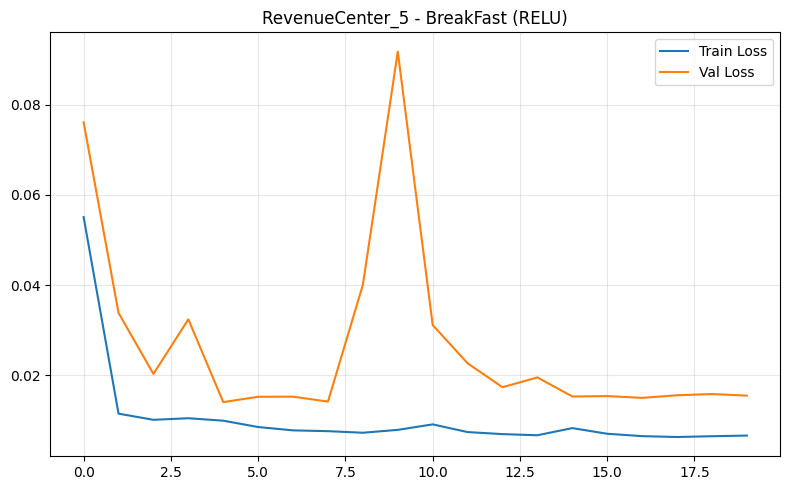

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


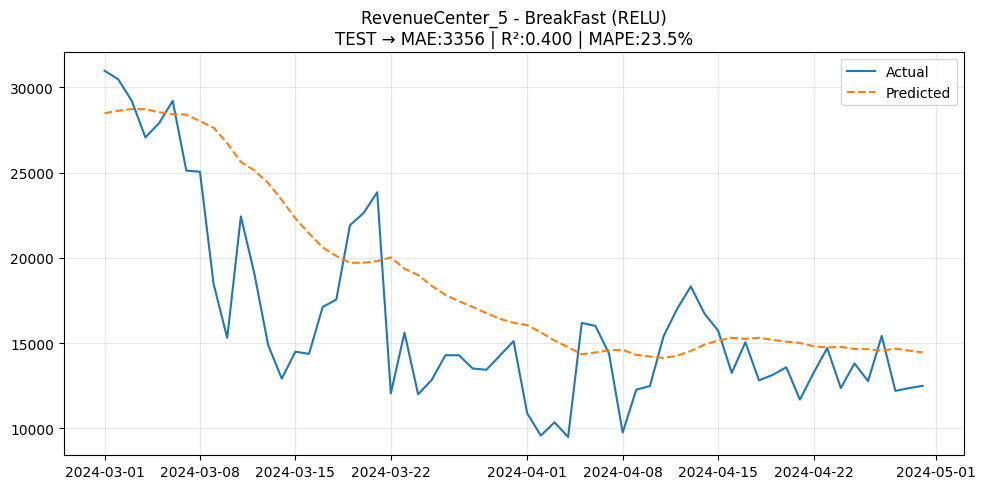

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - loss: 0.0149 - val_loss: 0.0176
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0146 - val_loss: 0.0161
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0144 - val_loss: 0.0177
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0119 - val_loss: 0.0161
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0191 - val_loss: 0.0163
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0126 - val_loss: 0.0158
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0158 - val_loss: 0.0175
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0115 - val_loss: 0.0163
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0145 - val_loss: 0.0188
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0156 - val_loss: 0.0161
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0170 - val_loss: 0.0158
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

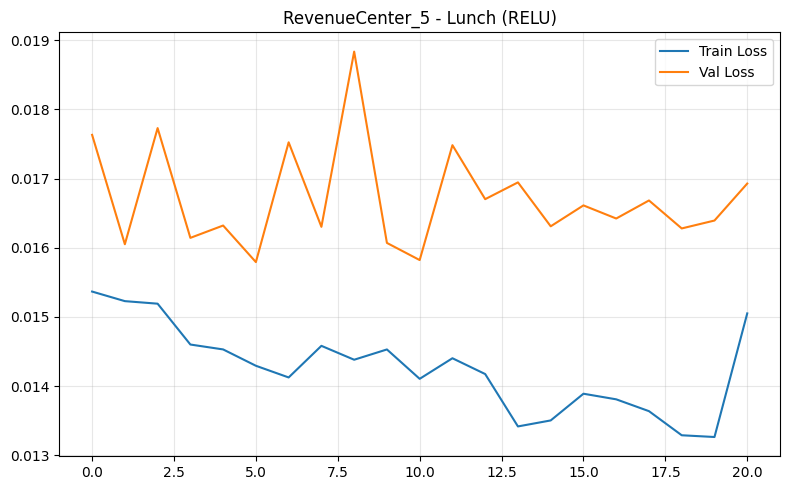

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


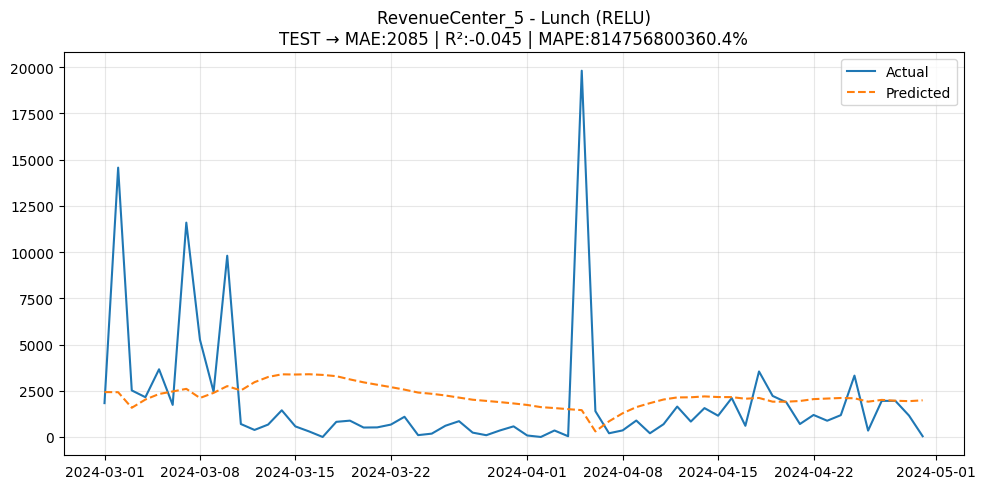

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - loss: 0.0284 - val_loss: 0.0565
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0199 - val_loss: 0.0532
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0206 - val_loss: 0.0542
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0216 - val_loss: 0.0570
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0180 - val_loss: 0.0548
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0194 - val_loss: 0.0555
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0167 - val_loss: 0.0564
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0212 - val_loss: 0.0586
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0208 - val_loss: 0.0597
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0190 - val_loss: 0.0582
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0170 - val_loss: 0.0565
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.

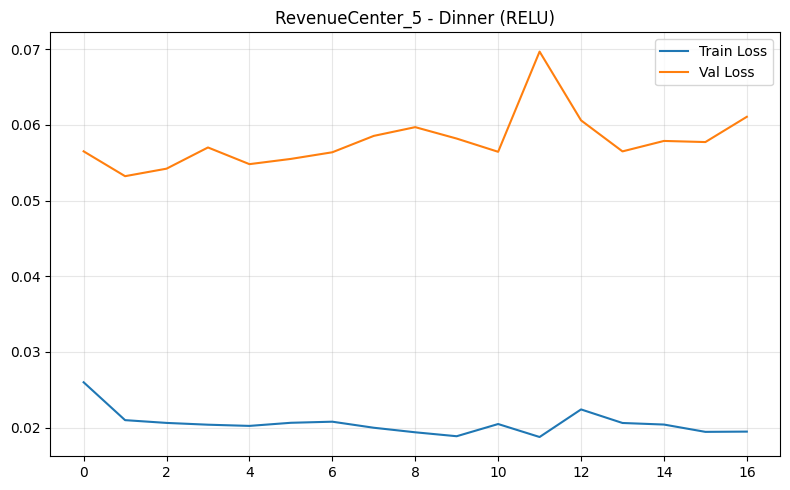

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


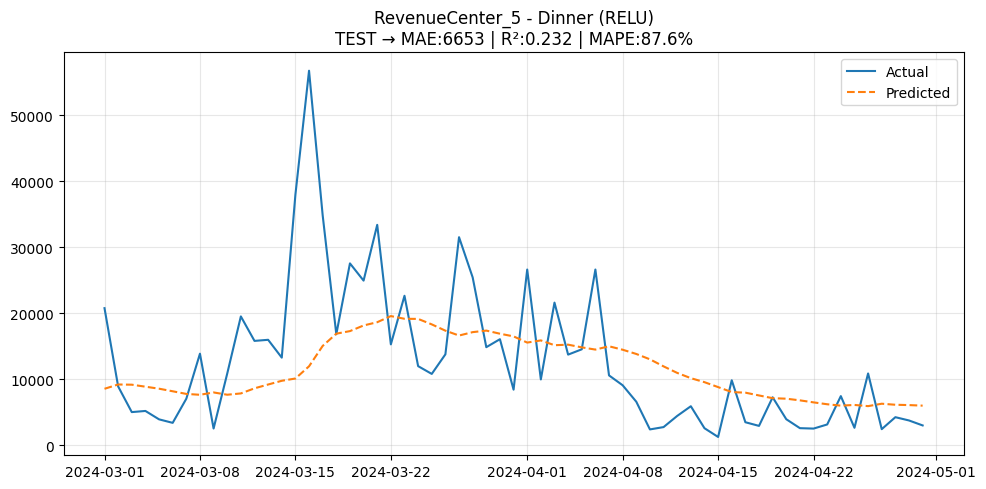

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - loss: 0.0101 - val_loss: 0.0048
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0075 - val_loss: 0.0046
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0080 - val_loss: 0.0046
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 0.0047
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0069 - val_loss: 0.0047
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0082 - val_loss: 0.0047
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0095 - val_loss: 0.0047
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0099 - val_loss: 0.0046
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0097 - val_loss: 0.0047
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0092 - val_loss: 0.0047
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0093 - val_loss: 0.0047
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

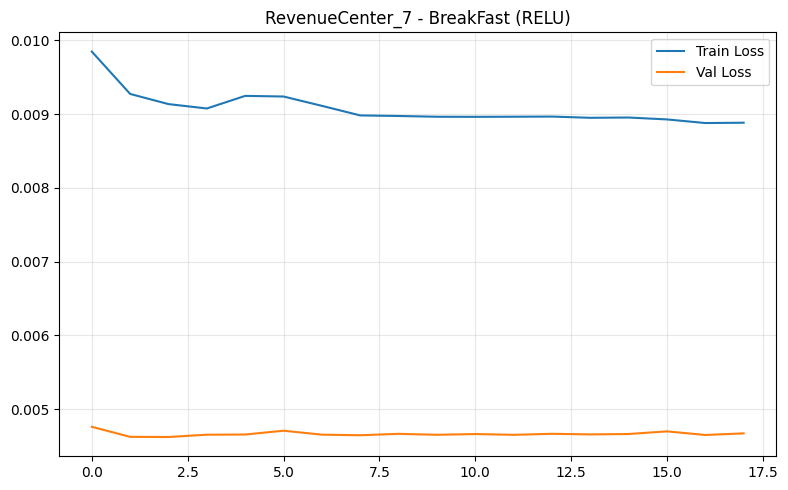

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


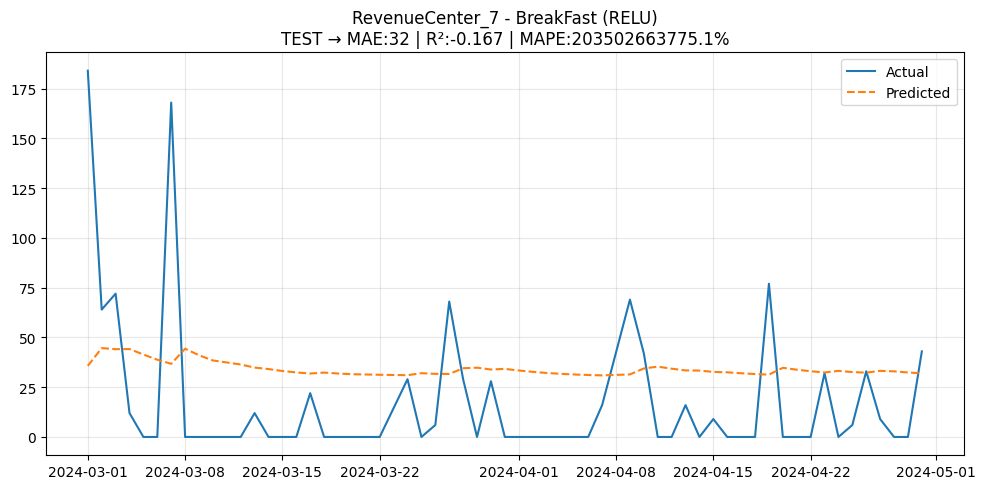

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - loss: 0.0120 - val_loss: 0.0408
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0096 - val_loss: 0.0392
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0106 - val_loss: 0.0403
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0101 - val_loss: 0.0396
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0089 - val_loss: 0.0403
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0117 - val_loss: 0.0399
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0112 - val_loss: 0.0409
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0126 - val_loss: 0.0397
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0114 - val_loss: 0.0404
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0103 - val_loss: 0.0401
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0110 - val_loss: 0.0403
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

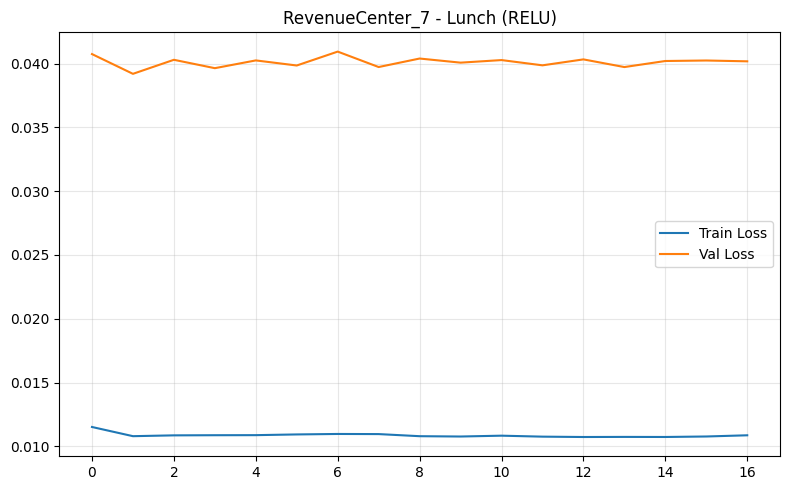

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


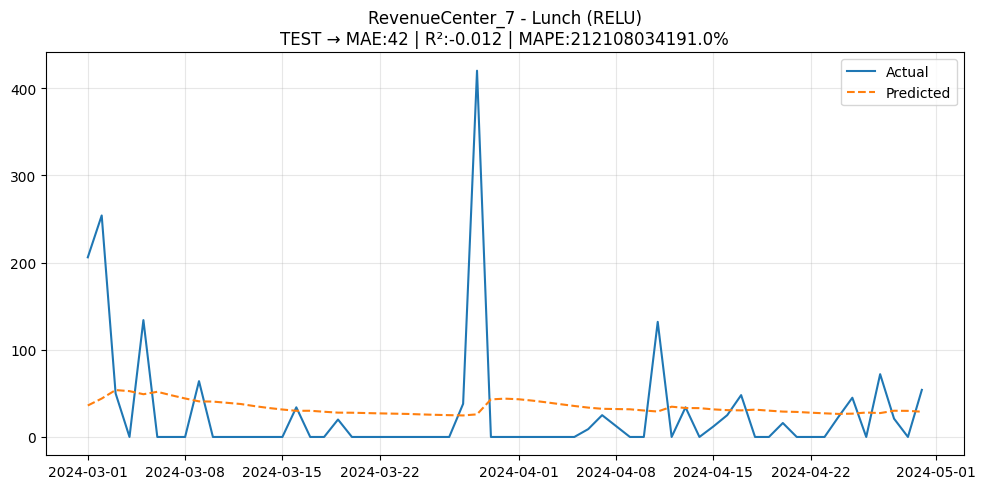

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - loss: 0.0237 - val_loss: 0.0906
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0191 - val_loss: 0.0779
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0203 - val_loss: 0.0855
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0191 - val_loss: 0.0796
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0186 - val_loss: 0.0826
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0183 - val_loss: 0.0799
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0190 - val_loss: 0.0812
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0197 - val_loss: 0.0800
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0161 - val_loss: 0.0793
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0213 - val_loss: 0.0852
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0190 - val_loss: 0.0792
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.

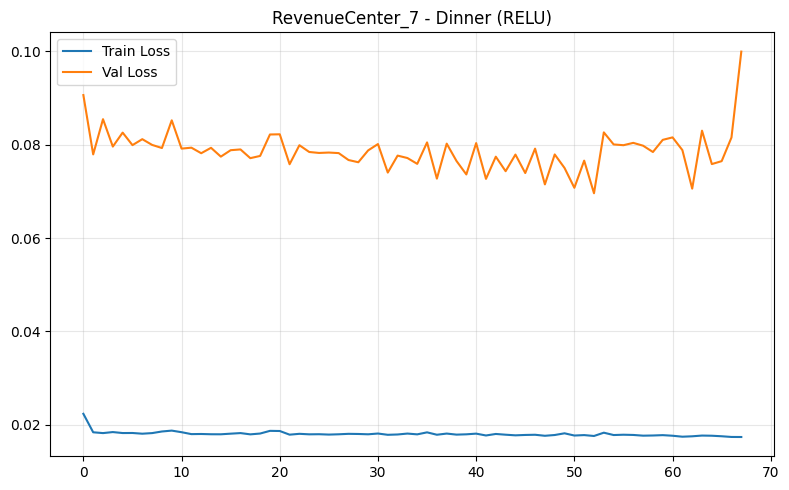

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


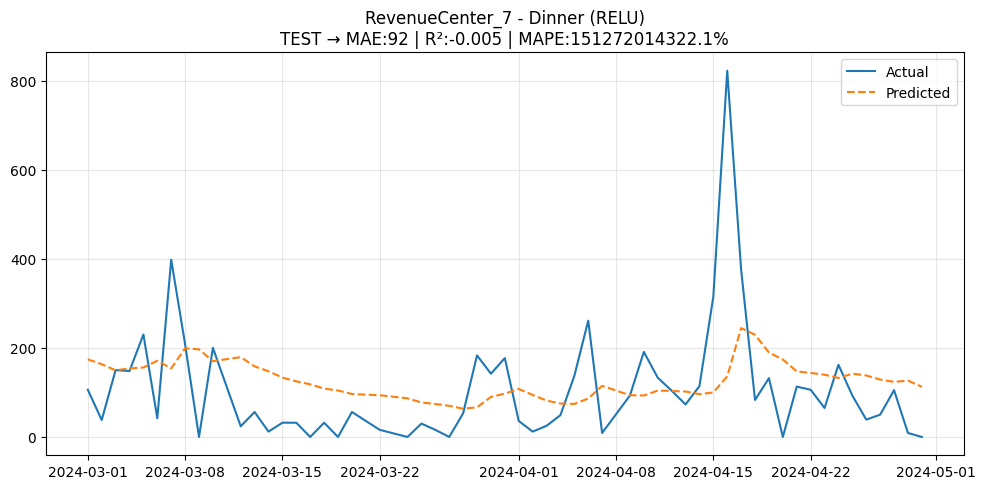

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 0.0221 - val_loss: 0.0336
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0189 - val_loss: 0.0223
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0158 - val_loss: 0.0285
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0181 - val_loss: 0.0251
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0193 - val_loss: 0.0286
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0154 - val_loss: 0.0234
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0138 - val_loss: 0.0244
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0164 - val_loss: 0.0240
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0178 - val_loss: 0.0243
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0132 - val_loss: 0.0243
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0129 - val_loss: 0.0265
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

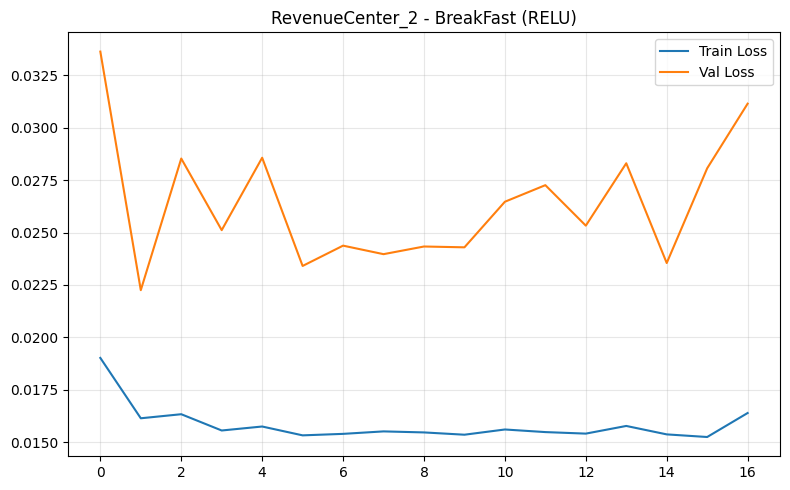

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 490ms/step


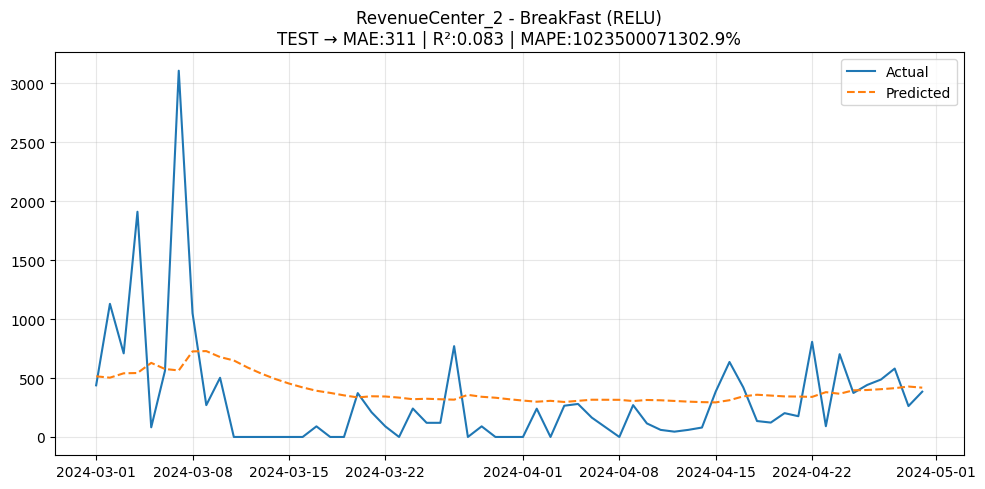

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - loss: 0.0237 - val_loss: 0.0641
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0151 - val_loss: 0.0611
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0165 - val_loss: 0.0609
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0584
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0182 - val_loss: 0.0645
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0142 - val_loss: 0.0557
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0216 - val_loss: 0.0791
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0196 - val_loss: 0.0662
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0176 - val_loss: 0.0610
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0162 - val_loss: 0.0624
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0185 - val_loss: 0.0642
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/ste

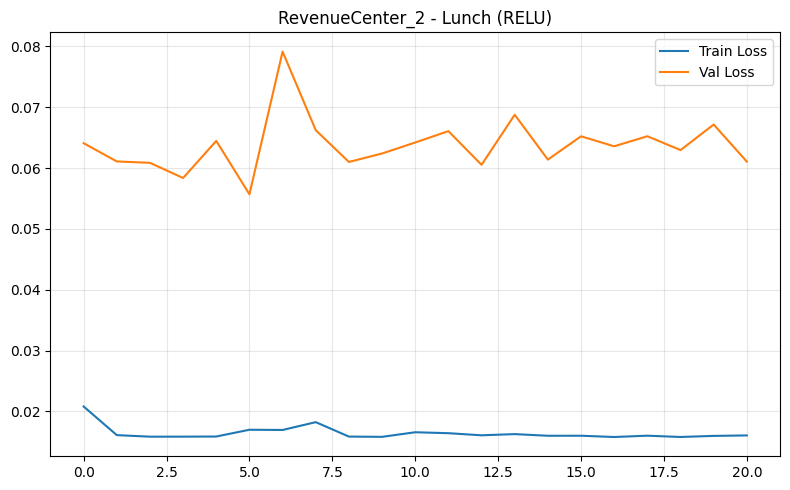

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


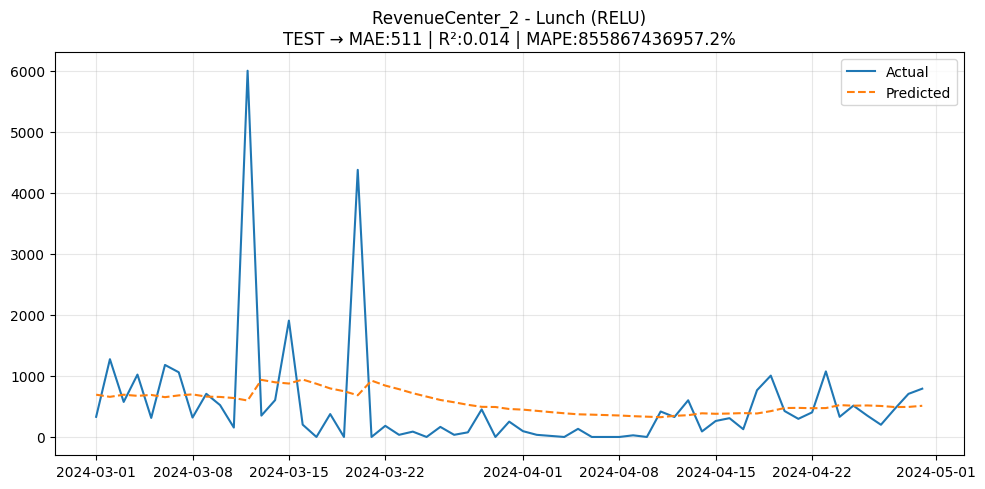

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - loss: 0.0018 - val_loss: 0.0280
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0016 - val_loss: 0.0273
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - val_loss: 0.0281
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0275
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0016 - val_loss: 0.0282
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0284
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - val_loss: 0.0277
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - val_loss: 0.0283
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013 - val_loss: 0.0272
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - val_loss: 0.0297
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0023 - val_loss: 0.0277
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/ste

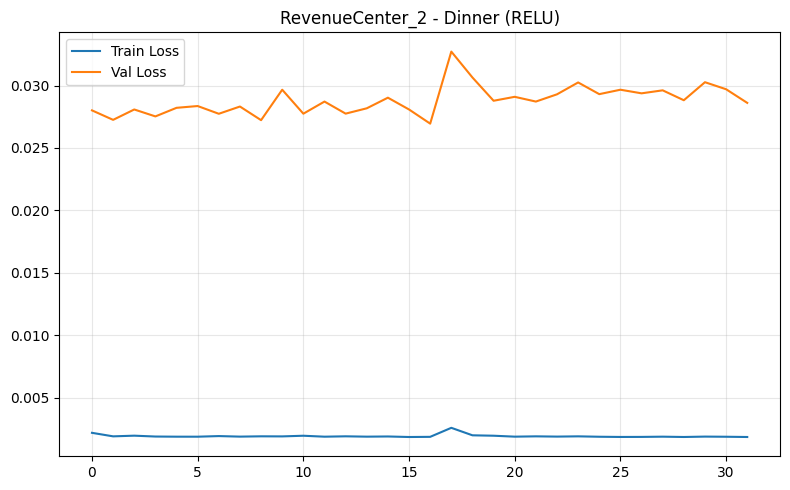

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 484ms/step


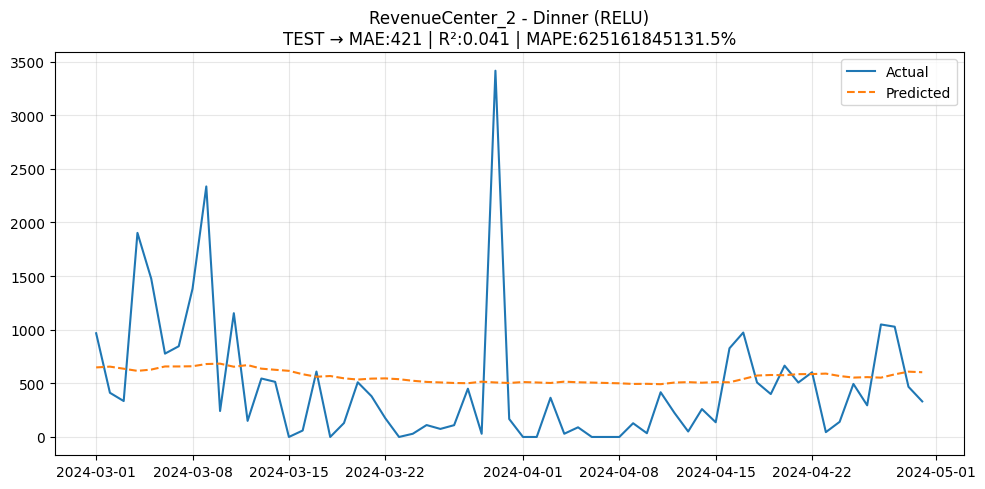

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - loss: 0.0068 - val_loss: 0.0398
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0058 - val_loss: 0.0329
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0048 - val_loss: 0.0295
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0048 - val_loss: 0.0317
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0051 - val_loss: 0.0290
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059 - val_loss: 0.0270
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0042 - val_loss: 0.0276
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - val_loss: 0.0404
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070 - val_loss: 0.0290
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045 - val_loss: 0.0288
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0044 - val_loss: 0.0359
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

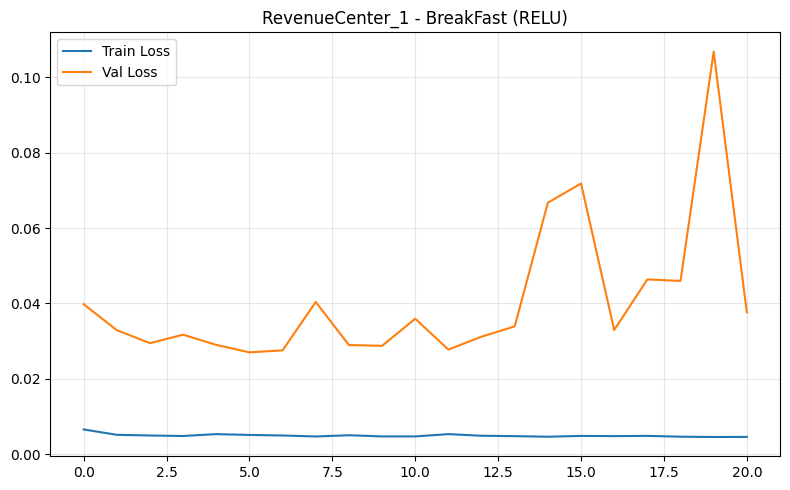

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step


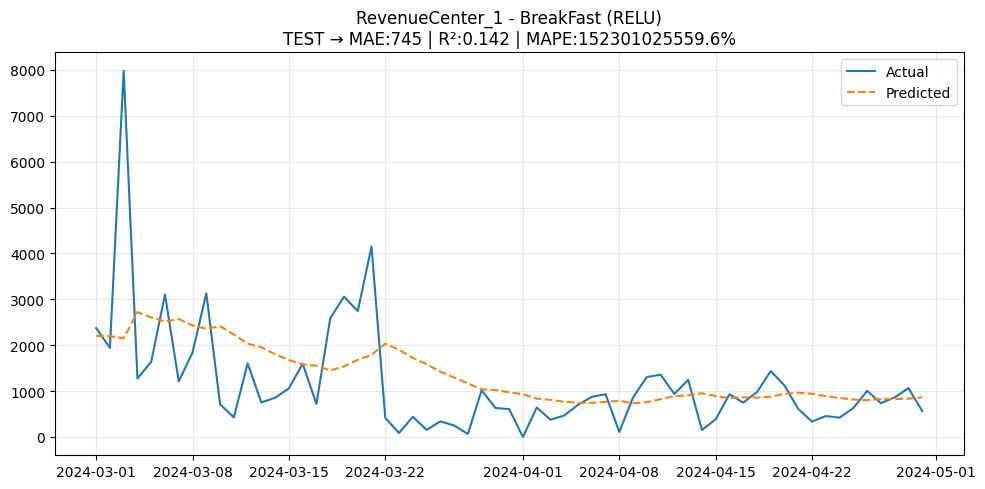

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - loss: 0.0201 - val_loss: 0.0899
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0086 - val_loss: 0.0668
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0130 - val_loss: 0.0713
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0101 - val_loss: 0.0698
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0141 - val_loss: 0.0713
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0121 - val_loss: 0.0667
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0109 - val_loss: 0.0674
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0092 - val_loss: 0.0678
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0130 - val_loss: 0.0694
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0121 - val_loss: 0.0667
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0122 - val_loss: 0.0724
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/ste

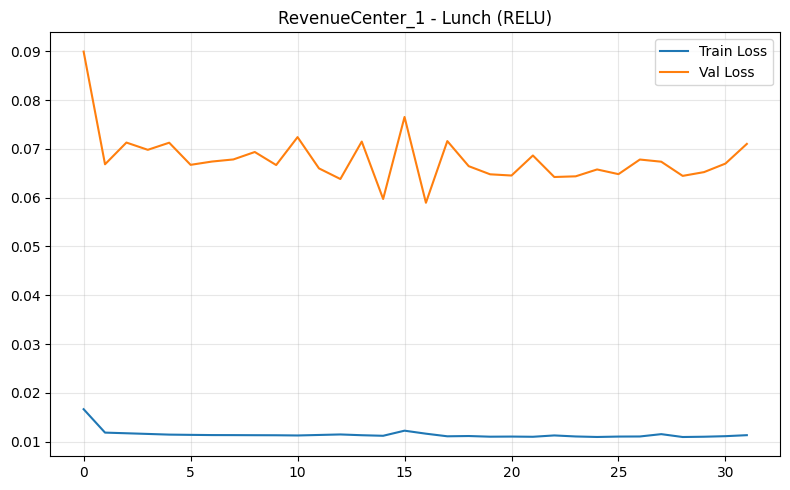

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


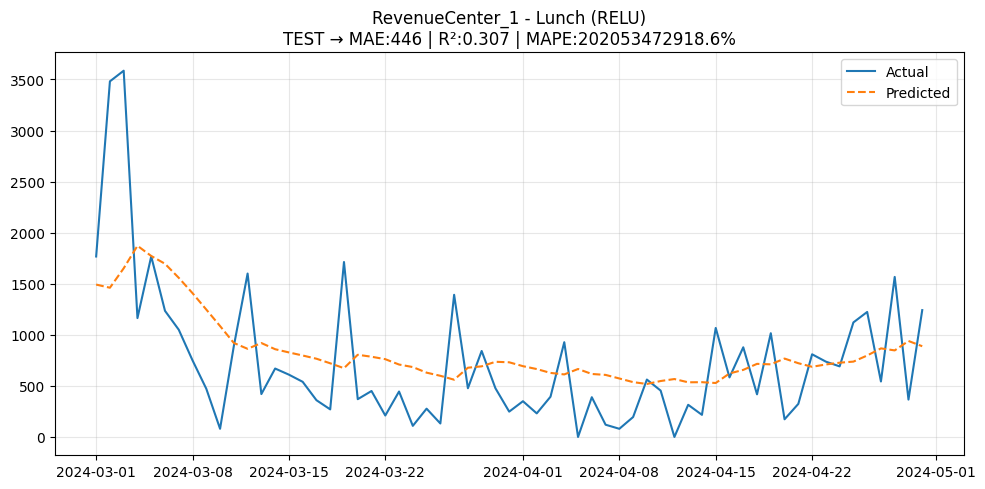

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - loss: 0.0342 - val_loss: 0.0434
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0132 - val_loss: 0.0398
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0101 - val_loss: 0.0304
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0112 - val_loss: 0.0253
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0134 - val_loss: 0.0279
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0114 - val_loss: 0.0291
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0141 - val_loss: 0.0301
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0148 - val_loss: 0.0407
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0093 - val_loss: 0.0275
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0383
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0126 - val_loss: 0.0278
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/ste

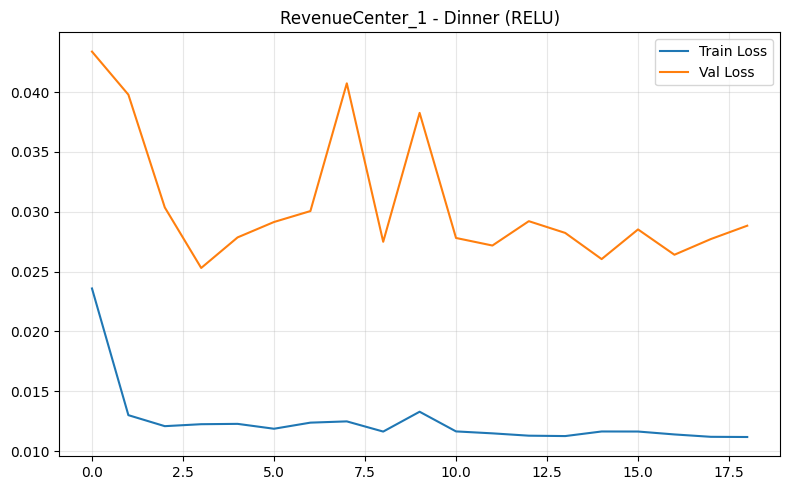

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


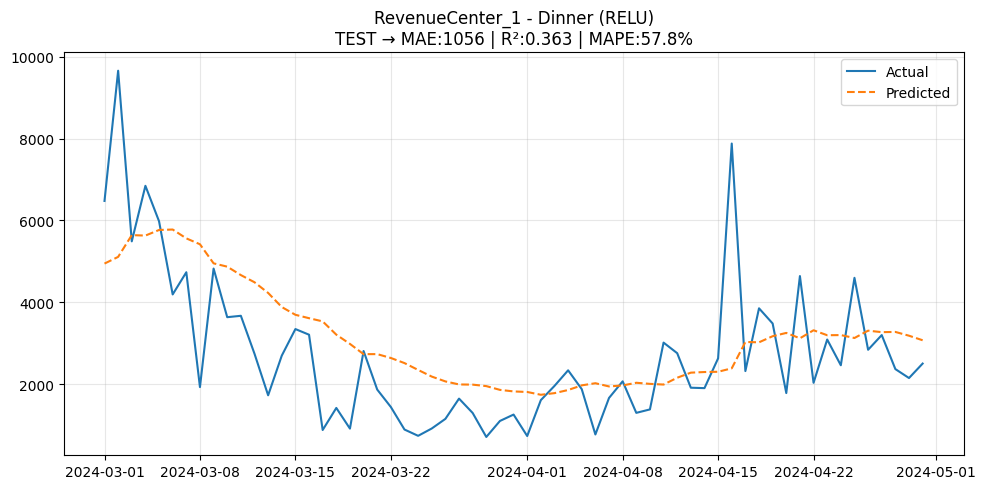

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - loss: 0.0257 - val_loss: 0.0529
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0219 - val_loss: 0.0489
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0216 - val_loss: 0.0491
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0253 - val_loss: 0.0493
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0233 - val_loss: 0.0493
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0227 - val_loss: 0.0495
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0223 - val_loss: 0.0496
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0202 - val_loss: 0.0496
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0230 - val_loss: 0.0494
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0226 - val_loss: 0.0494
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0186 - val_loss: 0.0494
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

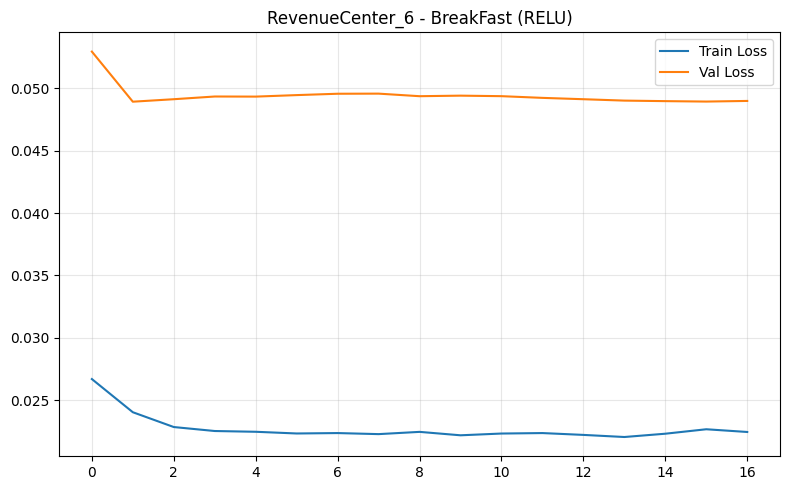

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


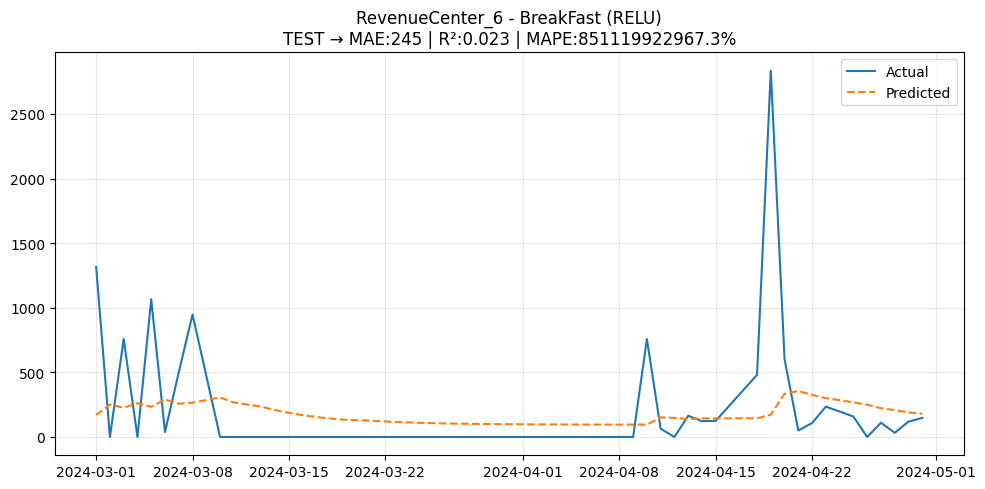

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - loss: 0.0118 - val_loss: 0.0220
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0121 - val_loss: 0.0190
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0097 - val_loss: 0.0183
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0117 - val_loss: 0.0209
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0131 - val_loss: 0.0186
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0088 - val_loss: 0.0187
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0089 - val_loss: 0.0190
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0092 - val_loss: 0.0189
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0099 - val_loss: 0.0191
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0126 - val_loss: 0.0195
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0086 - val_loss: 0.0189
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

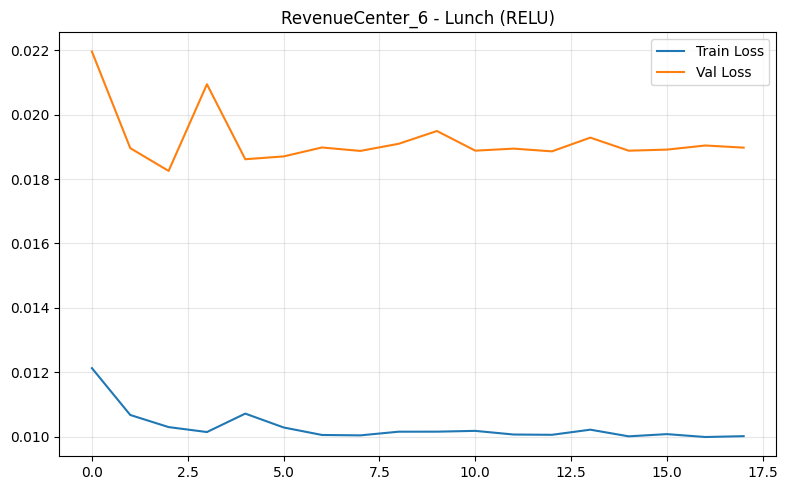

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


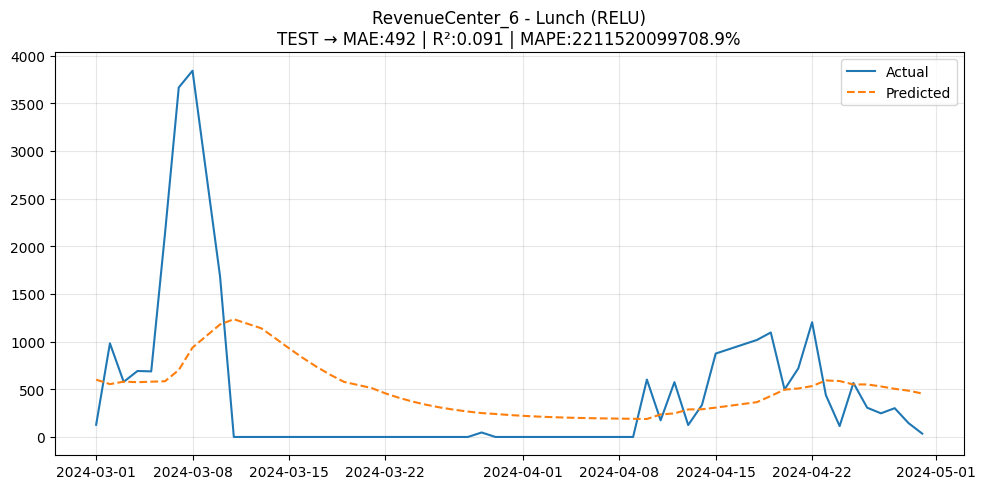

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - loss: 0.0054 - val_loss: 0.0253
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0072 - val_loss: 0.0249
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028 - val_loss: 0.0248
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018 - val_loss: 0.0247
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0026 - val_loss: 0.0248
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0050 - val_loss: 0.0249
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0038 - val_loss: 0.0247
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0023 - val_loss: 0.0249
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0019 - val_loss: 0.0247
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012 - val_loss: 0.0248
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028 - val_loss: 0.0247
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

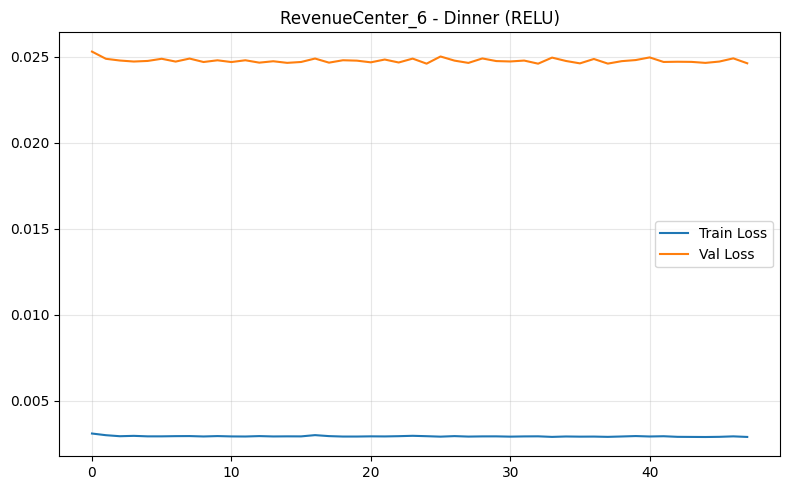

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


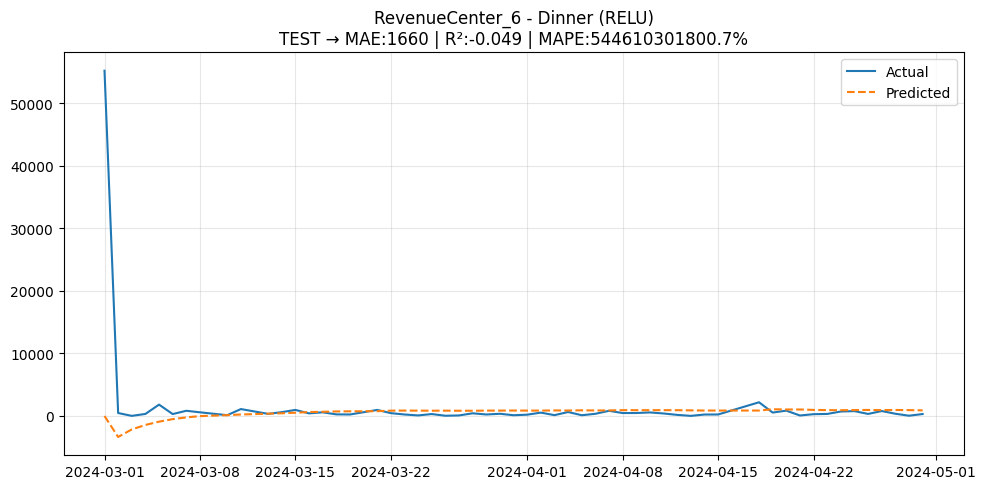

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - loss: 0.0022 - val_loss: 6.1884e-06
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0027 - val_loss: 7.9897e-06
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.8296e-04 - val_loss: 2.0306e-06
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0033 - val_loss: 4.2385e-05
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017 - val_loss: 2.7140e-06
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0081 - val_loss: 1.7094e-06
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0010 - val_loss: 1.8417e-06
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0014 - val_loss: 2.1718e-05
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_loss: 1.4603e-05
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0055 - val_loss: 6.4431e-06
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.8315e-04 - val_loss: 3.1881e-08
Epoch 12/30

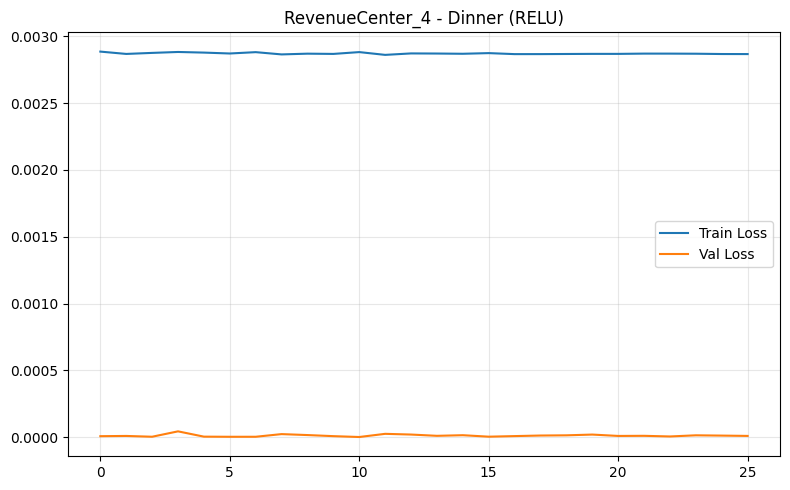

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


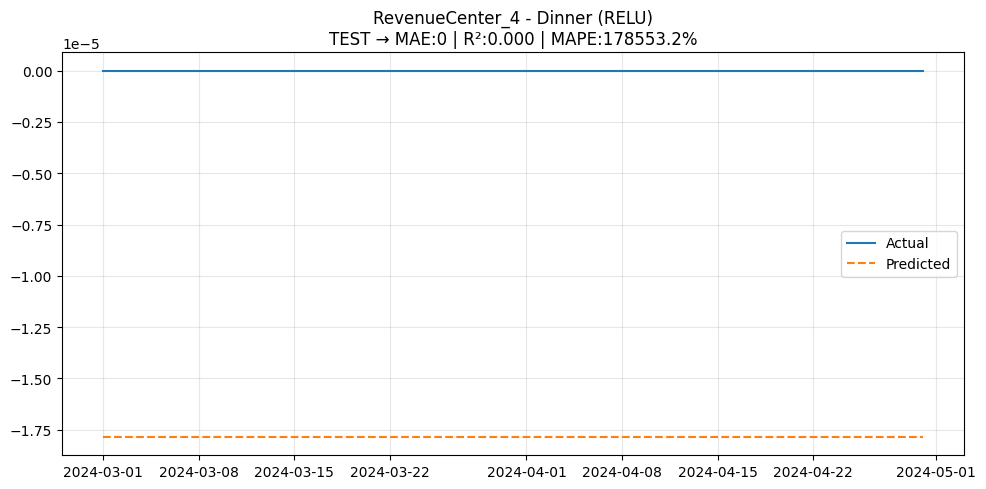

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 277ms/step - loss: 0.0132 - val_loss: 0.0023
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0145 - val_loss: 0.0024
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0075 - val_loss: 0.0024
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0047 - val_loss: 0.0024
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0061 - val_loss: 0.0024
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0139 - val_loss: 0.0024
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0097 - val_loss: 0.0024
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0055 - val_loss: 0.0023
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0102 - val_loss: 0.0024
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0114 - val_loss: 0.0024
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0085 - val_loss: 0.0024
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

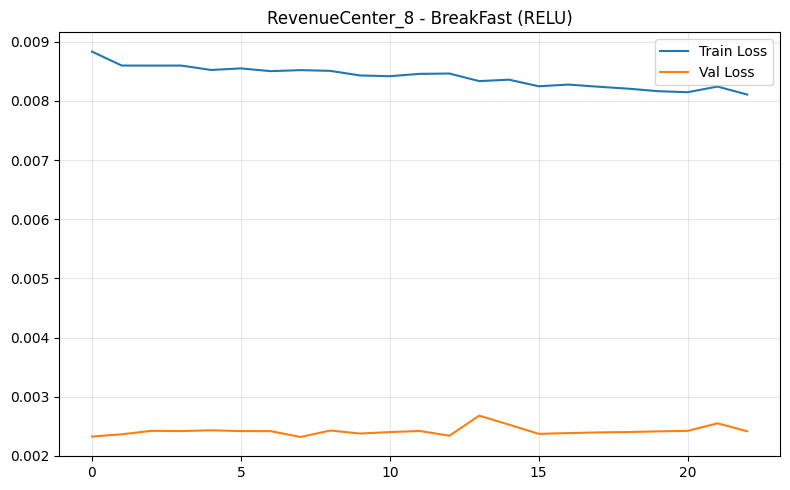

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


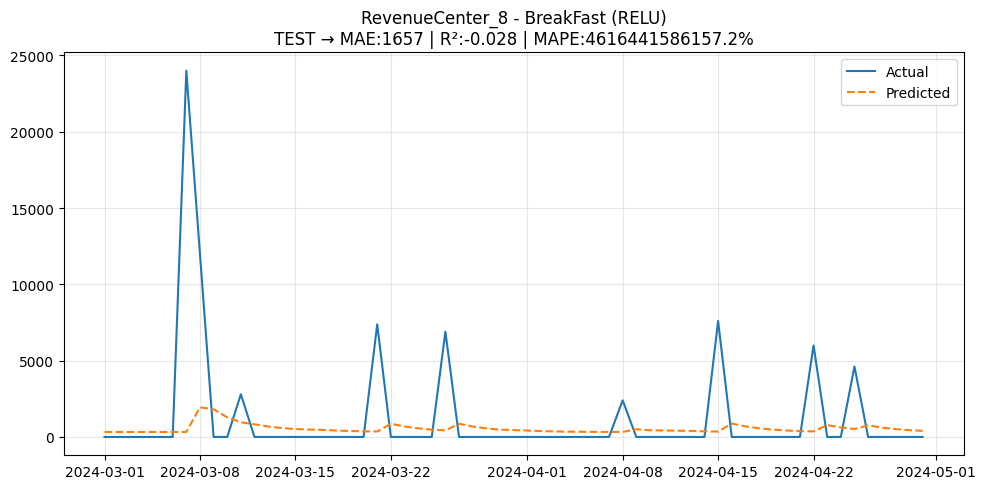

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - loss: 0.0165 - val_loss: 0.1012
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0143 - val_loss: 0.0972
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0142 - val_loss: 0.0998
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0129 - val_loss: 0.0935
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0128 - val_loss: 0.0997
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0140 - val_loss: 0.0988
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0146 - val_loss: 0.0949
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0169 - val_loss: 0.0964
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0139 - val_loss: 0.1004
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0149 - val_loss: 0.0943
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0147 - val_loss: 0.0976
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

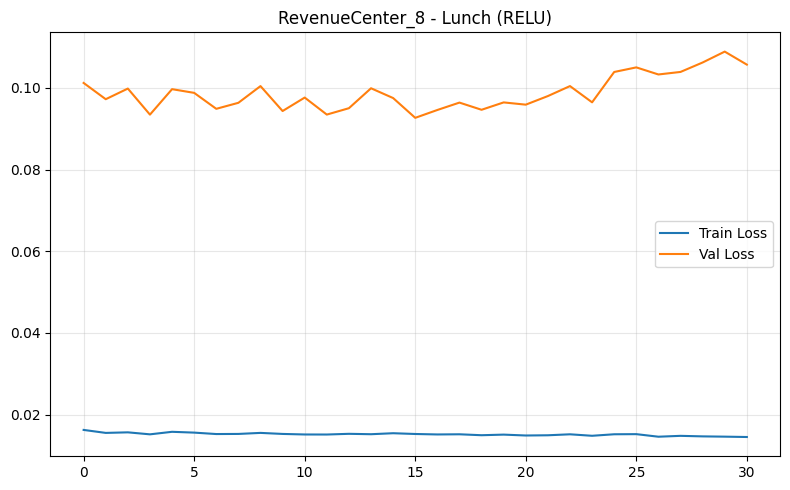

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


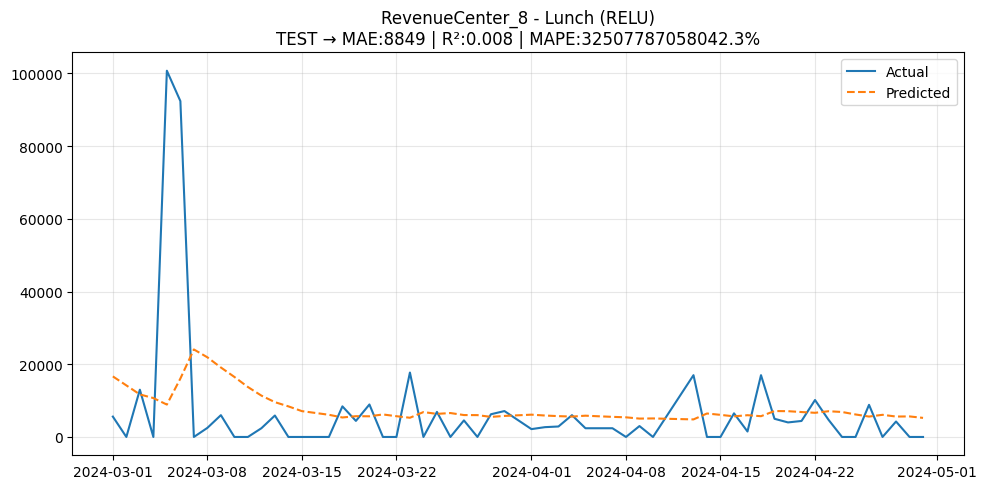

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - loss: 0.0165 - val_loss: 0.0536
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0127 - val_loss: 0.0562
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0111 - val_loss: 0.0556
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0116 - val_loss: 0.0515
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0143 - val_loss: 0.0568
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0131 - val_loss: 0.0539
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0128 - val_loss: 0.0539
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0144 - val_loss: 0.0555
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0124 - val_loss: 0.0526
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0123 - val_loss: 0.0540
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0122 - val_loss: 0.0550
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/ste

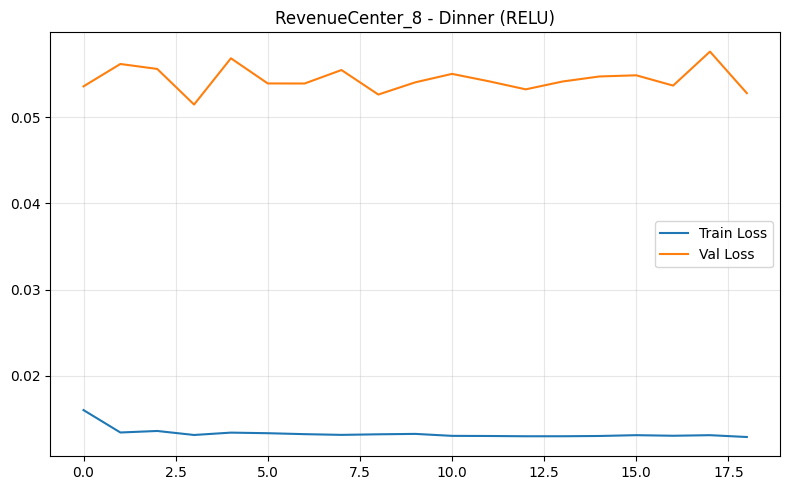

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


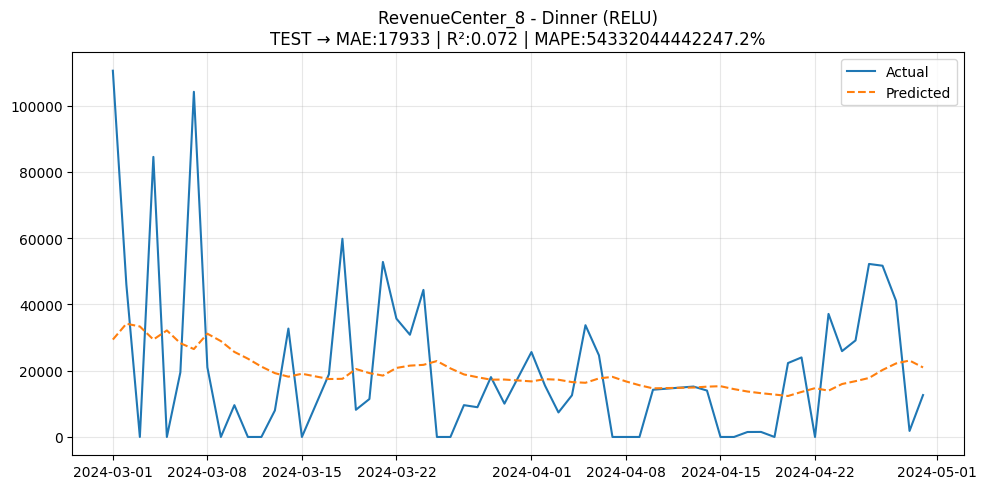

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - loss: 0.0330 - val_loss: 0.0458
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0246 - val_loss: 0.0365
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0257 - val_loss: 0.0385
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0220 - val_loss: 0.0373
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0234 - val_loss: 0.0393
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0222 - val_loss: 0.0390
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0229 - val_loss: 0.0371
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0228 - val_loss: 0.0376
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0221 - val_loss: 0.0372
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0228 - val_loss: 0.0404
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0211 - val_loss: 0.0410
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

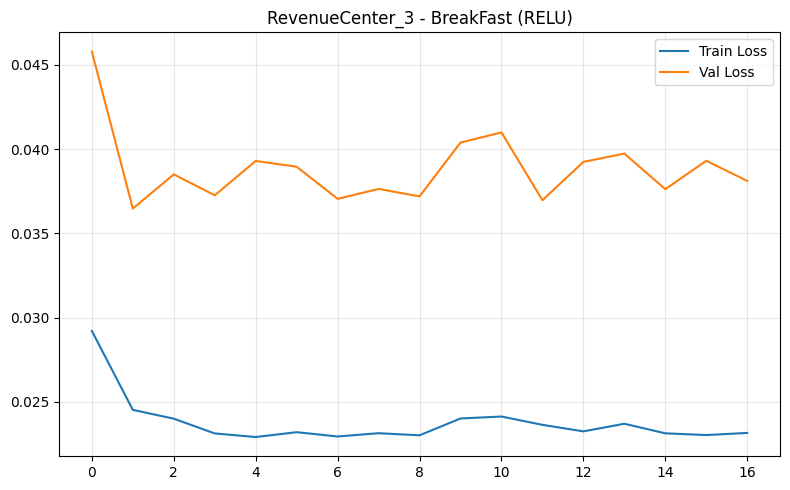

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


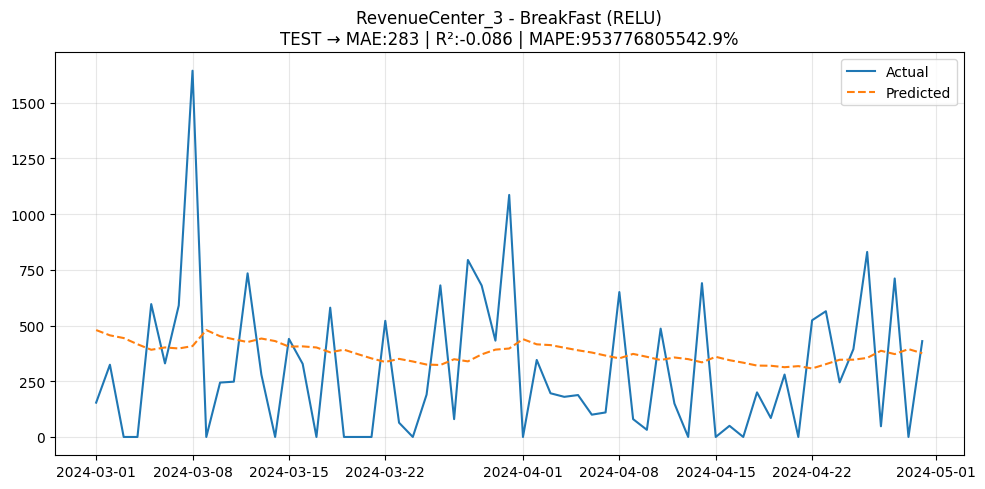

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - loss: 0.0208 - val_loss: 0.0677
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0111 - val_loss: 0.0468
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0093 - val_loss: 0.0570
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0098 - val_loss: 0.0516
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0094 - val_loss: 0.0525
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0087 - val_loss: 0.0568
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0095 - val_loss: 0.0515
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0116 - val_loss: 0.0569
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0097 - val_loss: 0.0540
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0099 - val_loss: 0.0555
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0091 - val_loss: 0.0478
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

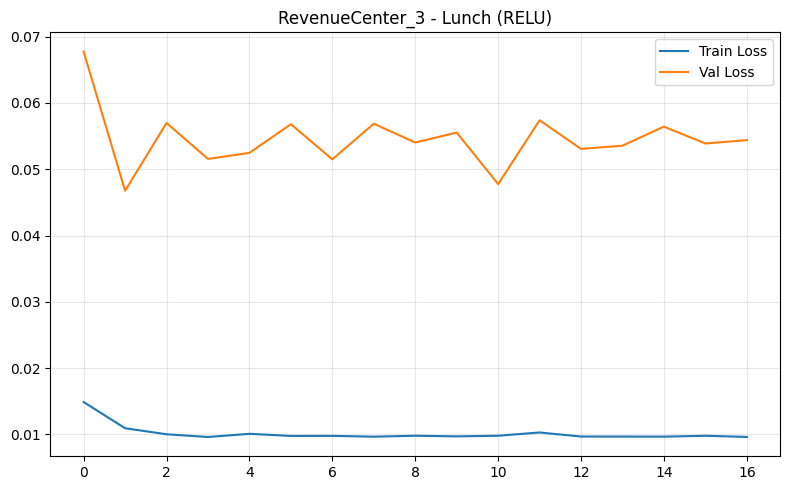

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


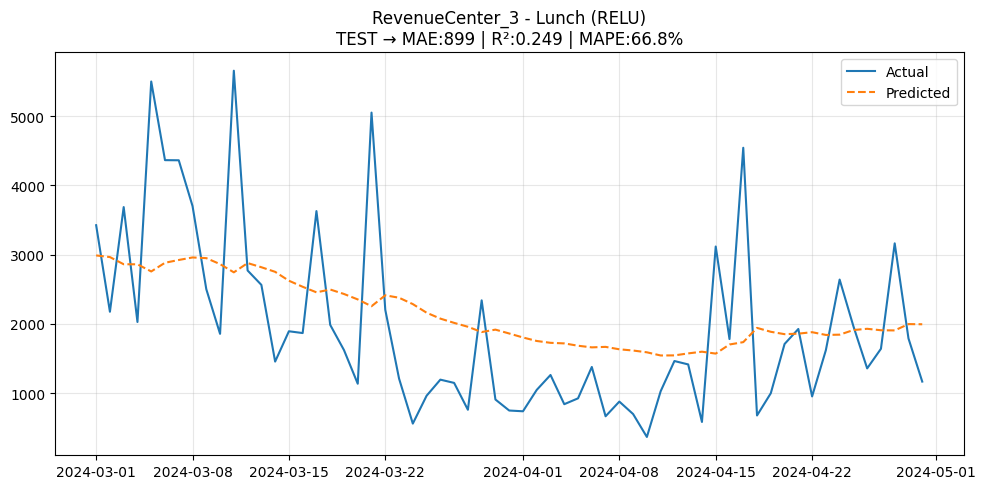

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - loss: 0.0388 - val_loss: 0.1410
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0147 - val_loss: 0.0480
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0092 - val_loss: 0.0717
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0099 - val_loss: 0.0672
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0092 - val_loss: 0.0584
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0093 - val_loss: 0.0458
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0100 - val_loss: 0.0451
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0344
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0103 - val_loss: 0.0410
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0103 - val_loss: 0.0341
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - val_loss: 0.0480
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

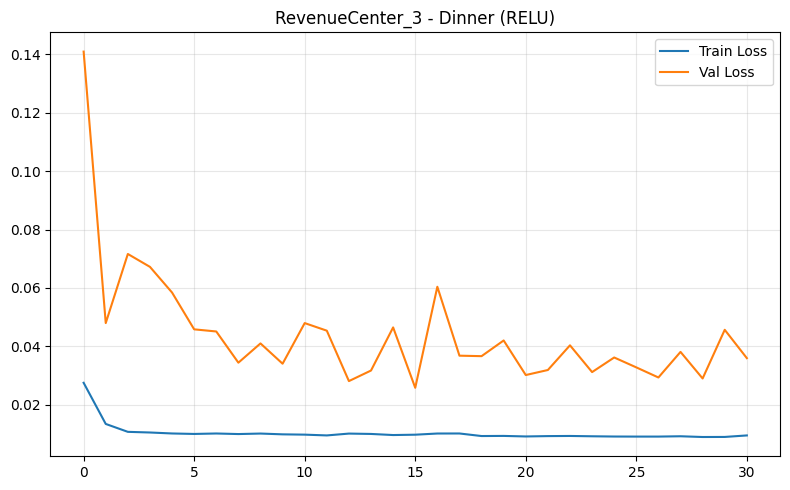

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


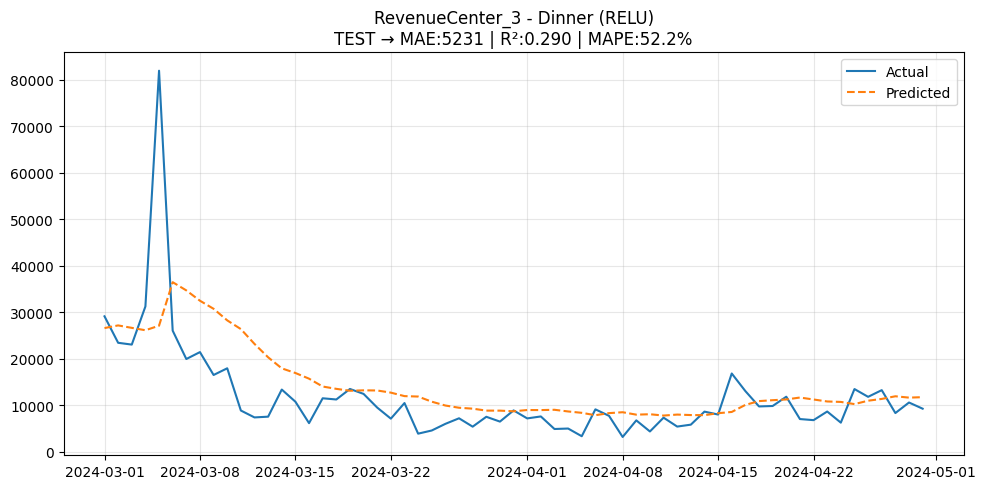

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - loss: 0.0119 - val_loss: 0.0887
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0100 - val_loss: 0.0806
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0068 - val_loss: 0.0729
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0088 - val_loss: 0.0741
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0087 - val_loss: 0.0710
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0059 - val_loss: 0.0645
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0090 - val_loss: 0.0648
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0076 - val_loss: 0.0635
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0082 - val_loss: 0.0586
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0104 - val_loss: 0.0687
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0082 - val_loss: 0.0613
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/ste

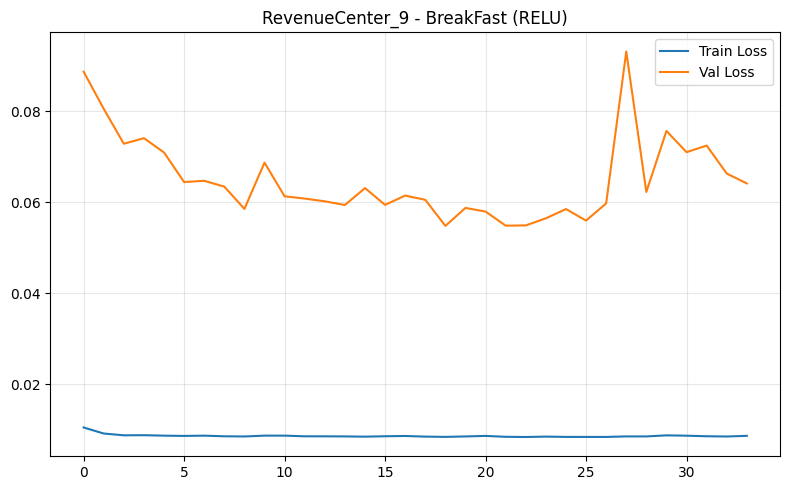

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


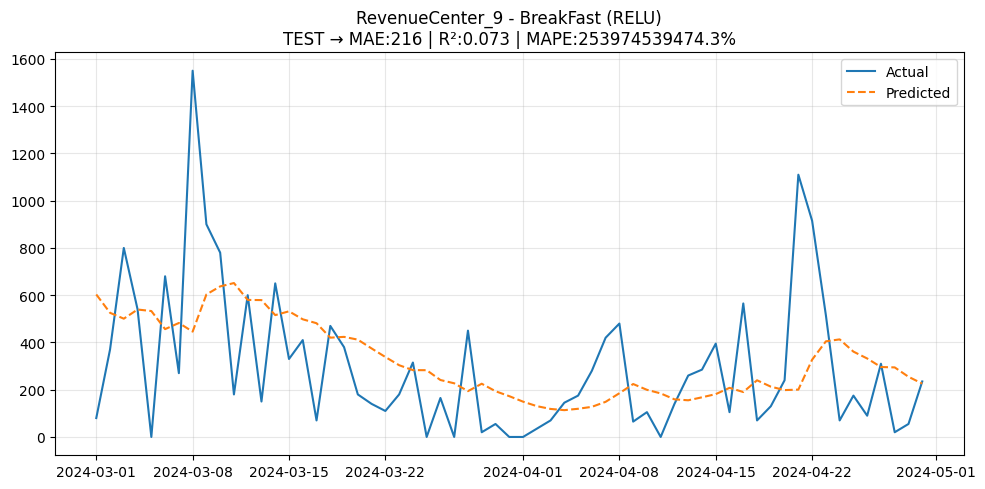

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - loss: 0.0527 - val_loss: 0.0524
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0367 - val_loss: 0.0455
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0334 - val_loss: 0.0489
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0268 - val_loss: 0.0456
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0273 - val_loss: 0.0481
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0313 - val_loss: 0.0458
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0350 - val_loss: 0.0466
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0311 - val_loss: 0.0468
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0296 - val_loss: 0.0461
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0353 - val_loss: 0.0479
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0311 - val_loss: 0.0480
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/ste

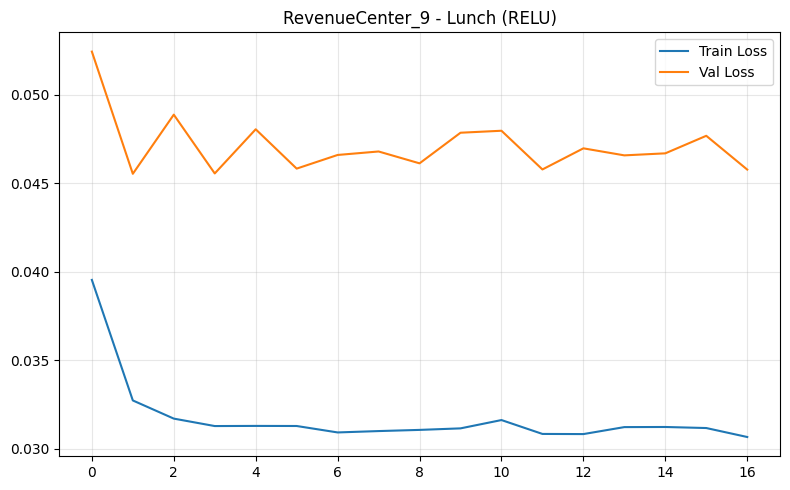

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


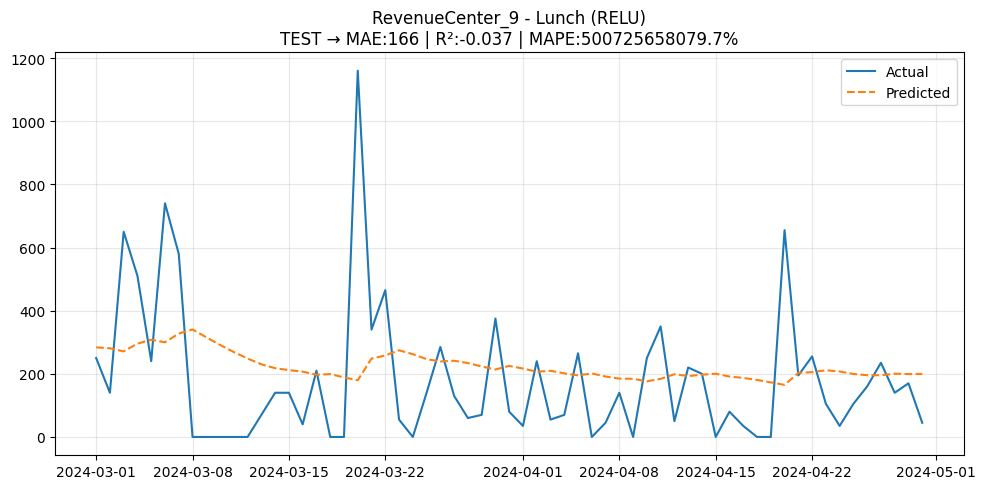

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - loss: 0.0265 - val_loss: 0.0135
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0206 - val_loss: 0.0150
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0216 - val_loss: 0.0141
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0207 - val_loss: 0.0143
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0267 - val_loss: 0.0142
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0240 - val_loss: 0.0142
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0254 - val_loss: 0.0145
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0169 - val_loss: 0.0142
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0215 - val_loss: 0.0149
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0204 - val_loss: 0.0144
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0259 - val_loss: 0.0147
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

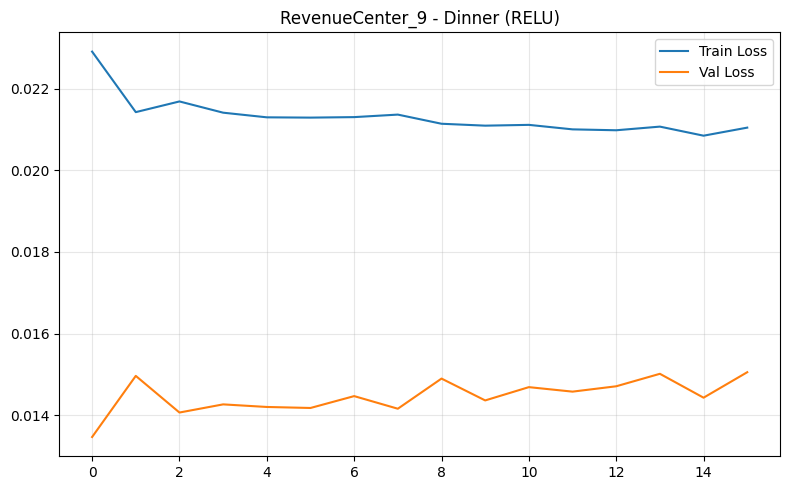

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 472ms/step


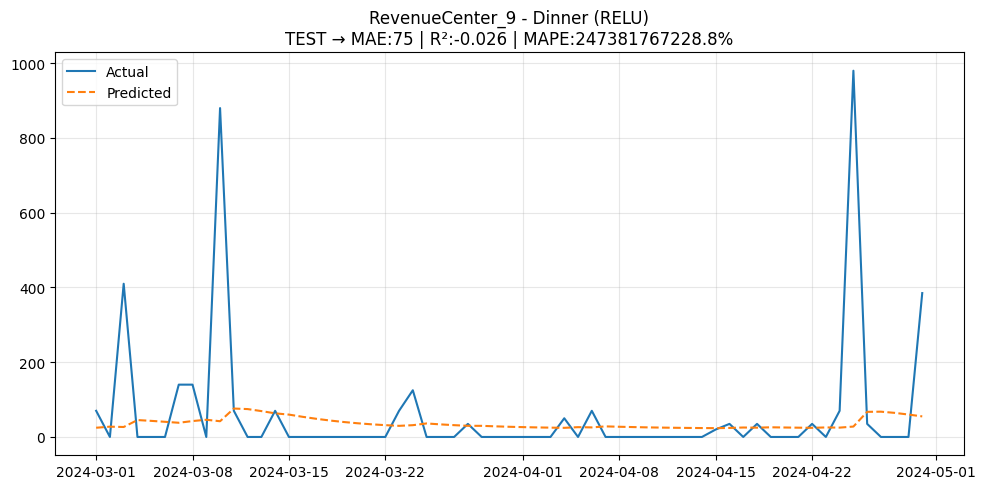

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — RELU MODEL


In [6]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — RELU
        # =========================
        model = Sequential([
            LSTM(
                512,
                activation="relu",
                recurrent_activation="sigmoid",
                input_shape=(WINDOW, 1)
            ),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=300,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (RELU)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_relu.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (RELU)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — RELU MODEL")